# Exploratory Data Analysis: Aave v3 The Graph Extracts for Markov Calibration

This notebook performs a first-pass inspection of the **raw** Aave v3 payloads extracted from The Graph. The extracts feed the Health Factor reconstruction and the subsequent **Markov chain** calibration.

- **Baseline scenario:** 30-day window ending 15 March 2024 (`data/01_raw/baseline_mar2024/thegraph_hf_30d.json`)
- **Stress scenario:** 30-day window ending 5 August 2024 (`data/01_raw/stress_aug2024/thegraph_hf_30d.json`) — loaded in a later notebook if needed

Each payload is expected to contain two primary collections: **`users`** (borrower positions, ~49k records) and **`liquidationCalls`** (liquidation events inside the 30-day window). Nested reserve histories (`aTokenBalanceHistory`, `vTokenBalanceHistory`, `sTokenBalanceHistory`) are the time-series ingredients for Health Factor paths.

## 1. Imports

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "legend.frameon": True,
        "axes.spines.top": False,
    }
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 80)

## 2. Data loading

The baseline JSON is resolved relative to this notebook (`notebooks/`). The file is large (~250 MB); `json.load` materializes the full payload in memory.

In [3]:
BASELINE_JSON_PATH = Path("../data/01_raw/baseline_mar2024/thegraph_hf_30d.json")

print(f"Resolved path: {BASELINE_JSON_PATH.resolve()}")
print(f"File exists: {BASELINE_JSON_PATH.exists()}")
print(f"File size (MB): {BASELINE_JSON_PATH.stat().st_size / 1e6:.1f}")

with BASELINE_JSON_PATH.open("r", encoding="utf-8") as handle:
    baseline_payload = json.load(handle)

print(f"Loaded payload type: {type(baseline_payload).__name__}")

Resolved path: C:\Users\facun\Repos\Tesina\data\01_raw\baseline_mar2024\thegraph_hf_30d.json
File exists: True
File size (MB): 252.1
Loaded payload type: dict


## 3. JSON structure inspection

The extractor writes metadata fields alongside the two GraphQL collections. The collections required for Markov calibration are **`users`** and **`liquidationCalls`**. Lengths should match the extraction logs (~49k borrowers).

In [4]:
print("Top-level keys:")
for key in baseline_payload.keys():
    print(f"  - {key}")

print()
for collection_name in ("users", "liquidationCalls"):
    collection = baseline_payload[collection_name]
    print(
        f"{collection_name}: type={type(collection).__name__}, "
        f"n_records={len(collection):,}"
    )

print()
print("Extractor metadata (if present):")
for meta_key in (
    "protocol",
    "network",
    "window_days",
    "start_datetime_utc",
    "end_datetime_utc",
    "user_count",
    "liquidation_call_count",
):
    if meta_key in baseline_payload:
        print(f"  {meta_key}: {baseline_payload[meta_key]}")

Top-level keys:
  - protocol
  - network
  - subgraph_id
  - window_days
  - start_timestamp
  - end_timestamp
  - start_datetime_utc
  - end_datetime_utc
  - extracted_at_utc
  - user_count
  - liquidation_call_count
  - users
  - liquidationCalls

users: type=list, n_records=49,299
liquidationCalls: type=list, n_records=113

Extractor metadata (if present):
  protocol: aave-v3
  network: ethereum
  window_days: 30
  start_datetime_utc: 2024-02-14T00:00:00+00:00
  end_datetime_utc: 2024-03-15T00:00:00+00:00
  user_count: 49299
  liquidation_call_count: 113


## 4. Conversion to DataFrames

### 4.1 Users

Each row is one borrower. Nested objects (`eModeCategoryId`, `reserves`) are stored as Python objects in object-dtype columns.

In [5]:
users_df = pd.DataFrame(baseline_payload["users"])

print(f"users_df shape: {users_df.shape}")
display(users_df.head())
users_df.info()

users_df shape: (49299, 4)


,id,borrowedReservesCount,eModeCategoryId,reserves
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1,"{'id': '1', 'ltv': '9300', 'liquidationThreshold': '9500', 'liquidationBonus...",[{'id': '0x0000000000004f3d8aaf9175fd824cb00ad4bf800x7f39c581f595b53c5cb19bd...
1,0x000000000000bb1b11e5ac8099e92e366b64c133,1,None,[{'id': '0x000000000000bb1b11e5ac8099e92e366b64c1330x2260fac5e5542a773aa44fb...
2,0x00000000002088951336d7972746a135f2956417,1,"{'id': '1', 'ltv': '9300', 'liquidationThreshold': '9500', 'liquidationBonus...",[{'id': '0x00000000002088951336d7972746a135f29564170x7f39c581f595b53c5cb19bd...
3,0x00000015e180b01c40b881e10774bc784bb6f4eb,1,None,[{'id': '0x00000015e180b01c40b881e10774bc784bb6f4eb0xae78736cd615f374d308512...
4,0x000000ae384600d7252543855e3b0400f6008d00,1,None,[{'id': '0x000000ae384600d7252543855e3b0400f6008d000xa0b86991c6218b36c1d19d4...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49299 entries, 0 to 49298
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     49299 non-null  object
 1   borrowedReservesCount  49299 non-null  int64 
 2   eModeCategoryId        5567 non-null   object
 3   reserves               49299 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.5+ MB


### 4.2 Liquidation calls

Each row is one `liquidationCall` event inside the 30-day baseline window.

In [6]:
liquidation_calls_df = pd.DataFrame(baseline_payload["liquidationCalls"])

print(f"liquidation_calls_df shape: {liquidation_calls_df.shape}")
display(liquidation_calls_df.head())
liquidation_calls_df.info()

liquidation_calls_df shape: (113, 12)


,id,txHash,action,timestamp,liquidator,collateralAmount,principalAmount,collateralAssetPriceUSD,borrowAssetPriceUSD,user,collateralReserve,principalReserve
0,19225169:6:0x632efc14507f2e99c6e8530cc9c9b40a1baa73fb5453b5c896b2b9acafe91c8...,0x632efc14507f2e99c6e8530cc9c9b40a1baa73fb5453b5c896b2b9acafe91c8f,LiquidationCall,1707901115,0x6fb323bc0a1c0e5991bfc2088b02b6185d8d4232,5577051147,10636177,1.00006323,0,{'id': '0xd6198a8bacf40e2f75a8fde04332ee459d8ac451'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0x2260fac5e5542a773aa44fbcfedf7c193bc2c5990x2f39d218133afab8f2b819b1...
1,19225177:11:0x7ab35bd9e6a5fe8e4417f7abdcca399c88d727d6b14b51b294aff9bf0759ca...,0x7ab35bd9e6a5fe8e4417f7abdcca399c88d727d6b14b51b294aff9bf0759caf4,LiquidationCall,1707901211,0x165af4e54495387096eb573fddfbcf8178ba7e9d,2510767916,891030786569377024,1.00024218,1782.44,{'id': '0xc3608e238949fa912d3e30a16e8e646a193cd9d6'},{'id': '0xdac17f958d2ee523a2206206994597c13d831ec70x2f39d218133afab8f2b819b1...,{'id': '0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc20x2f39d218133afab8f2b819b1...
2,19225205:5:0xa0bf33e4bfa5d7c383a81acc6b68a629659e6e303f211b6f54bac58c16a9a02...,0xa0bf33e4bfa5d7c383a81acc6b68a629659e6e303f211b6f54bac58c16a9a020,LiquidationCall,1707901547,0x681d0d7196a036661b354fa2a7e3b73c2adc43ec,7056468290,2500990181124742663,1.00006323,1782.44,{'id': '0xc13c405334bc11b48c1125972d9d1ce1eb601d30'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc20x2f39d218133afab8f2b819b1...
3,19225236:4:0xf471a7d0b578439e7aa01eea0bce5cb9d7f731841b0dd14023eedee57c337cb...,0xf471a7d0b578439e7aa01eea0bce5cb9d7f731841b0dd14023eedee57c337cb1,LiquidationCall,1707901931,0x681d0d7196a036661b354fa2a7e3b73c2adc43ec,4019186910,7577439,1.00006323,0,{'id': '0x48f497dcadfbfe92fc70a50859e13c666b87978f'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0x2260fac5e5542a773aa44fbcfedf7c193bc2c5990x2f39d218133afab8f2b819b1...
4,19228383:25:0x614d5b272af24bd0c425ae0241cb6542e5106817e924036c43174635ea1c66...,0x614d5b272af24bd0c425ae0241cb6542e5106817e924036c43174635ea1c6627,LiquidationCall,1707940163,0x000000005bcf85aad6ed1d32db5490deddfc97f9,889190475,310575278527215232,1.00006323,1782.44,{'id': '0xd7962bdf93344c6938e2d07aa3f8f9457b4b212c'},{'id': '0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb480x2f39d218133afab8f2b819b1...,{'id': '0xc02aaa39b223fe8d0a0e5c4f27ead9083c756cc20x2f39d218133afab8f2b819b1...


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   id                       113 non-null    object
 1   txHash                   113 non-null    object
 2   action                   113 non-null    object
 3   timestamp                113 non-null    int64 
 4   liquidator               113 non-null    object
 5   collateralAmount         113 non-null    object
 6   principalAmount          113 non-null    object
 7   collateralAssetPriceUSD  113 non-null    object
 8   borrowAssetPriceUSD      113 non-null    object
 9   user                     113 non-null    object
 10  collateralReserve        113 non-null    object
 11  principalReserve         113 non-null    object
dtypes: int64(1), object(11)
memory usage: 10.7+ KB


## 5. Nested completeness and live-debt example

Position history for Health Factor reconstruction lives **inside** each user: `reserves` is a list of per-asset snapshots, and each reserve may contain `aTokenBalanceHistory`, `vTokenBalanceHistory`, and `sTokenBalanceHistory`.

This cell:

1. Identifies nested (list/dict) columns in `users_df`.
2. Summarizes how often those nested histories are non-empty.
3. Prints one borrower with `borrowedReservesCount > 0` as a structural example.

Nested / object columns in users_df:
  - id: str
  - eModeCategoryId: dict (keys=['id', 'ltv', 'liquidationThreshold', 'liquidationBonus', 'label'])
  - reserves: list (example length=3)

Users: 49,299
Users with borrowedReservesCount > 0: 49,299
Users with a non-empty reserves list: 49,299
Total nested reserve records: 170,953
Reserves with non-empty 30-day histories:
  - aTokenBalanceHistory: 2,221
  - vTokenBalanceHistory: 2,488
  - sTokenBalanceHistory: 0

Example borrower with live debt (borrowedReservesCount > 0):
  id: 0x0000000000004f3d8aaf9175fd824cb00ad4bf80
  borrowedReservesCount: 1
  eModeCategoryId: {'id': '1', 'ltv': '9300', 'liquidationThreshold': '9500', 'liquidationBonus': '10100', 'label': 'ETH correlated'}
  n_reserves: 3

First nested reserve (structural sample):
  symbol: wstETH
  currentATokenBalance: 0
  currentVariableDebt: 0
  currentTotalDebt: 0
  len(aTokenBalanceHistory): 0
  len(vTokenBalanceHistory): 0
  len(sTokenBalanceHistory): 0


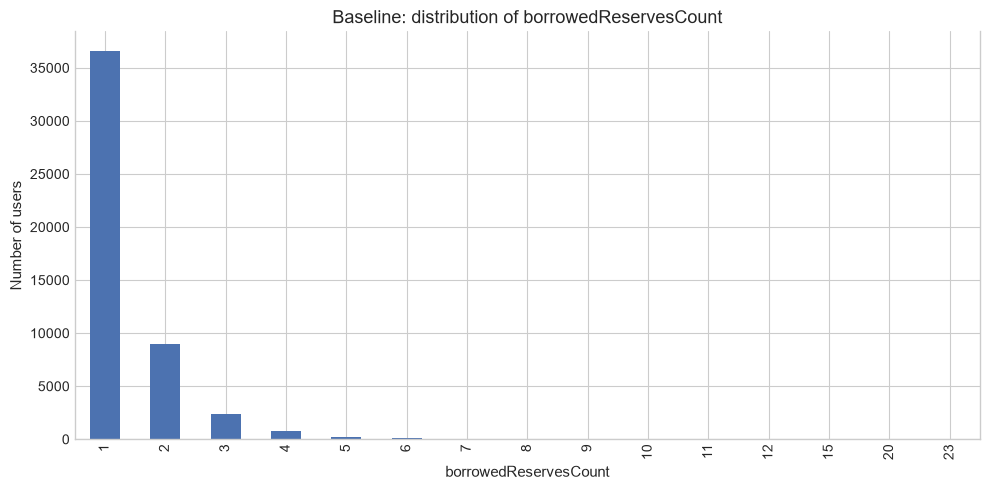

In [7]:
def classify_nested_column(series: pd.Series) -> str:
    """Return a short label for the first non-null nested Python type."""
    sample = series.dropna().iloc[0] if series.notna().any() else None
    if isinstance(sample, list):
        return f"list (example length={len(sample)})"
    if isinstance(sample, dict):
        return f"dict (keys={list(sample.keys())})"
    return type(sample).__name__


print("Nested / object columns in users_df:")
for column in users_df.columns:
    if users_df[column].dtype == "object":
        print(f"  - {column}: {classify_nested_column(users_df[column])}")

n_users = len(users_df)
n_with_reserves = users_df["reserves"].map(lambda value: isinstance(value, list) and len(value) > 0).sum()
n_live_debt = (users_df["borrowedReservesCount"] > 0).sum()

history_counts = {"aTokenBalanceHistory": 0, "vTokenBalanceHistory": 0, "sTokenBalanceHistory": 0}
n_reserves_total = 0
for reserves in users_df["reserves"]:
    if not isinstance(reserves, list):
        continue
    n_reserves_total += len(reserves)
    for reserve in reserves:
        if not isinstance(reserve, dict):
            continue
        for history_key in history_counts:
            history = reserve.get(history_key, [])
            if isinstance(history, list) and len(history) > 0:
                history_counts[history_key] += 1

print()
print(f"Users: {n_users:,}")
print(f"Users with borrowedReservesCount > 0: {n_live_debt:,}")
print(f"Users with a non-empty reserves list: {n_with_reserves:,}")
print(f"Total nested reserve records: {n_reserves_total:,}")
print("Reserves with non-empty 30-day histories:")
for history_key, count in history_counts.items():
    print(f"  - {history_key}: {count:,}")

live_debt_mask = users_df["borrowedReservesCount"] > 0
if not live_debt_mask.any():
    raise ValueError("No user with borrowedReservesCount > 0 was found in the baseline extract.")

example_user = users_df.loc[live_debt_mask].iloc[0]
example_reserves = example_user["reserves"] if isinstance(example_user["reserves"], list) else []

print()
print("Example borrower with live debt (borrowedReservesCount > 0):")
print(f"  id: {example_user['id']}")
print(f"  borrowedReservesCount: {example_user['borrowedReservesCount']}")
print(f"  eModeCategoryId: {example_user.get('eModeCategoryId')}")
print(f"  n_reserves: {len(example_reserves)}")

if example_reserves:
    example_reserve = example_reserves[0]
    reserve_meta = example_reserve.get("reserve", {})
    print()
    print("First nested reserve (structural sample):")
    print(f"  symbol: {reserve_meta.get('symbol')}")
    print(f"  currentATokenBalance: {example_reserve.get('currentATokenBalance')}")
    print(f"  currentVariableDebt: {example_reserve.get('currentVariableDebt')}")
    print(f"  currentTotalDebt: {example_reserve.get('currentTotalDebt')}")
    print(f"  len(aTokenBalanceHistory): {len(example_reserve.get('aTokenBalanceHistory') or [])}")
    print(f"  len(vTokenBalanceHistory): {len(example_reserve.get('vTokenBalanceHistory') or [])}")
    print(f"  len(sTokenBalanceHistory): {len(example_reserve.get('sTokenBalanceHistory') or [])}")

fig, ax = plt.subplots()
users_df["borrowedReservesCount"].value_counts().sort_index().plot(
    kind="bar", ax=ax, color="#4C72B0"
)
ax.set_title("Baseline: distribution of borrowedReservesCount")
ax.set_xlabel("borrowedReservesCount")
ax.set_ylabel("Number of users")
plt.tight_layout()
plt.show()

## 6. Flatten nested histories into a longitudinal panel

Each borrower stores collateral and variable-debt paths as **separate nested lists** (`aTokenBalanceHistory`, `vTokenBalanceHistory`) under `reserves`. Markov calibration needs a **long panel**: one row per `(user_id, reserve_symbol, timestamp)`.

**Constant-state rule.** The Graph only emits a history point when the scaled balance changes. If `currentATokenBalance` or `currentVariableDebt` is strictly greater than zero but the matching history list is empty, the position was live and **unchanged** over the 30-day window. Those balances are inferred at the window start and window end timestamps so the panel spans the full valuation interval.

Idle reserves (zero current balances and empty histories) are dropped. Collateral and debt series are aligned on the union of timestamps, with last-observation-carried-forward within each user-reserve.

In [8]:
def _as_int(value) -> int:
    """Coerce GraphQL numeric strings to int; missing values become 0."""
    if value in (None, ""):
        return 0
    return int(value)


def _history_by_timestamp(history, balance_key: str) -> dict[int, int]:
    """Map Unix timestamps to raw token balances (last write wins)."""
    points: dict[int, int] = {}
    if not history:
        return points
    for item in history:
        timestamp = _as_int(item.get("timestamp"))
        points[timestamp] = _as_int(item.get(balance_key))
    return points


def flatten_user_reserve_histories(
    users: list,
    window_start: int,
    window_end: int,
) -> list[tuple]:
    """Unnest Aave v3 user reserves into a longitudinal list of tuples.

    For each user-reserve the function:
    1. Collects aToken (collateral) and vToken (variable debt) history points.
    2. If a live current balance has an empty history, fills that constant
       balance at ``window_start`` and ``window_end``.
    3. Walks the union of timestamps and forward-fills the other side.

    Returns
    -------
    list[tuple]
        ``(user_id, timestamp, reserve_symbol, aToken_balance, vToken_balance)``
        with balances scaled by the reserve decimals.
    """
    rows: list[tuple] = []
    append = rows.append

    for user in users:
        user_id = user.get("id")
        for reserve in user.get("reserves") or ():
            meta = reserve.get("reserve") or {}
            symbol = meta.get("symbol") or "UNKNOWN"
            decimals = _as_int(meta.get("decimals")) or 18
            scale = 10 ** decimals

            a_map = _history_by_timestamp(
                reserve.get("aTokenBalanceHistory"),
                "currentATokenBalance",
            )
            v_map = _history_by_timestamp(
                reserve.get("vTokenBalanceHistory"),
                "currentVariableDebt",
            )
            a_now = _as_int(reserve.get("currentATokenBalance"))
            v_now = _as_int(reserve.get("currentVariableDebt"))

            # Constant collateral: live balance, no change events in the window.
            if not a_map and a_now > 0:
                a_map[window_start] = a_now
                a_map[window_end] = a_now
            # Constant variable debt: live balance, no change events in the window.
            if not v_map and v_now > 0:
                v_map[window_start] = v_now
                v_map[window_end] = v_now

            if not a_map and not v_map:
                continue

            last_a = 0
            last_v = 0
            for timestamp in sorted(a_map.keys() | v_map.keys()):
                if timestamp in a_map:
                    last_a = a_map[timestamp]
                if timestamp in v_map:
                    last_v = v_map[timestamp]
                append(
                    (
                        user_id,
                        timestamp,
                        symbol,
                        last_a / scale,
                        last_v / scale,
                    )
                )

    return rows

In [9]:
window_start = int(baseline_payload["start_timestamp"])
window_end = int(baseline_payload["end_timestamp"])

panel_rows = flatten_user_reserve_histories(
    baseline_payload["users"],
    window_start=window_start,
    window_end=window_end,
)

flat_panel_df = pd.DataFrame(
    panel_rows,
    columns=[
        "user_id",
        "timestamp",
        "reserve_symbol",
        "aToken_balance",
        "vToken_balance",
    ],
)
flat_panel_df["date"] = pd.to_datetime(flat_panel_df["timestamp"], unit="s", utc=True)
flat_panel_df = flat_panel_df[
    [
        "user_id",
        "timestamp",
        "date",
        "reserve_symbol",
        "aToken_balance",
        "vToken_balance",
    ]
]

n_constant_boundary = int(
    ((flat_panel_df["timestamp"] == window_start) | (flat_panel_df["timestamp"] == window_end)).sum()
)
print(f"Window: [{window_start}, {window_end}]")
print(f"Flattened rows: {len(flat_panel_df):,}")
print(f"Unique users: {flat_panel_df['user_id'].nunique():,}")
print(f"Unique reserves: {flat_panel_df['reserve_symbol'].nunique():,}")
print(f"Rows at window start or end (includes inferred constants): {n_constant_boundary:,}")

Window: [1707868800, 1710460800]
Flattened rows: 223,930
Unique users: 45,170
Unique reserves: 65
Rows at window start or end (includes inferred constants): 211,950


## 7. Flattened panel verification

Sort by `user_id` and `timestamp`, then inspect shape, dtypes, and the first ten rows.

In [10]:
flat_panel_df = flat_panel_df.sort_values(
    ["user_id", "timestamp"], kind="mergesort"
).reset_index(drop=True)

print(f"flat_panel_df.shape: {flat_panel_df.shape}")
print()
flat_panel_df.info()
print()
display(flat_panel_df.head(10))

flat_panel_df.shape: (223930, 6)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223930 entries, 0 to 223929
Data columns (total 6 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   user_id         223930 non-null  object             
 1   timestamp       223930 non-null  int64              
 2   date            223930 non-null  datetime64[ns, UTC]
 3   reserve_symbol  223930 non-null  object             
 4   aToken_balance  223930 non-null  float64            
 5   vToken_balance  223930 non-null  float64            
dtypes: datetime64[ns, UTC](1), float64(2), int64(1), object(2)
memory usage: 10.3+ MB



,user_id,timestamp,date,reserve_symbol,aToken_balance,vToken_balance
0,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1707868800,2024-02-14 00:00:00+00:00,WETH,0.000000e+00,2.000000e-18
1,0x0000000000004f3d8aaf9175fd824cb00ad4bf80,1710460800,2024-03-15 00:00:00+00:00,WETH,0.000000e+00,2.000000e-18
2,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,WBTC,1.000000e-08,0.000000e+00
3,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,USDC,0.000000e+00,1.268000e-03
4,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,WETH,5.050000e-07,0.000000e+00
5,0x000000000000bb1b11e5ac8099e92e366b64c133,1707868800,2024-02-14 00:00:00+00:00,USDT,9.997000e-03,0.000000e+00
6,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,WBTC,1.000000e-08,0.000000e+00
7,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,USDC,0.000000e+00,1.268000e-03
8,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,WETH,5.050000e-07,0.000000e+00
9,0x000000000000bb1b11e5ac8099e92e366b64c133,1710460800,2024-03-15 00:00:00+00:00,USDT,9.997000e-03,0.000000e+00
